In [22]:
import IPython.display as ipd
import librosa
import librosa.display
import pandas as pd
import os, time, warnings
import seaborn as sns
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Conv1D,
    MaxPooling1D,
    BatchNormalization,
    Dropout,
    Flatten,
    Conv2D,
    MaxPool2D,
)

warnings.filterwarnings("ignore")

In [4]:

import kagglehub

# Download latest version
path = kagglehub.dataset_download("sreyareddy15/esc10rearranged")

print("Path to dataset files:", path)

100%|██████████| 139M/139M [00:00<00:00, 152MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/sreyareddy15/esc10rearranged/versions/1


In [11]:
import os

print(os.listdir(path))

['Data']


In [13]:
import os

print(os.listdir(os.path.join(path, "Data")))

['helicopter', 'dog', 'sea_waves', 'crackling_fire', 'rooster', 'clock_tick', 'chainsaw', 'sneezing', 'crying_baby', 'rain']


In [14]:
DATA_PATH = os.path.join(path, "Data")

Ten kod przechodzi przez folder z danymi audio, zbiera wszystkie pliki .wav, przypisuje im klasy (nazwy folderów), a potem tworzy z tego tabelę DataFrame

In [15]:
def get_ds_paths(input_dir) -> []:
    input_files = []
    input_classes = []
    for dirs, subdirs, files in os.walk(input_dir):
        for file in files:
            if file.endswith('.wav'):
                input_files.append(file)
                input_classes.append(dirs.split('/')[-1])
    return np.array(input_files), np.array(input_classes)

files, classes = get_ds_paths(DATA_PATH)
data = { "file": files, "class": classes}
df = pd.DataFrame(data)
df

,file,class
0,1-172649-E-40.wav,helicopter
1,2-37806-A-40.wav,helicopter
2,5-220955-A-40.wav,helicopter
3,4-175000-A-40.wav,helicopter
4,5-177957-E-40.wav,helicopter
...,...,...
395,4-161127-A-10.wav,rain
396,2-101676-A-10.wav,rain
397,3-157149-A-10.wav,rain
398,1-50060-A-10.wav,rain


Sprawdzamy rozłożenie klas w naszym zbiorze danych

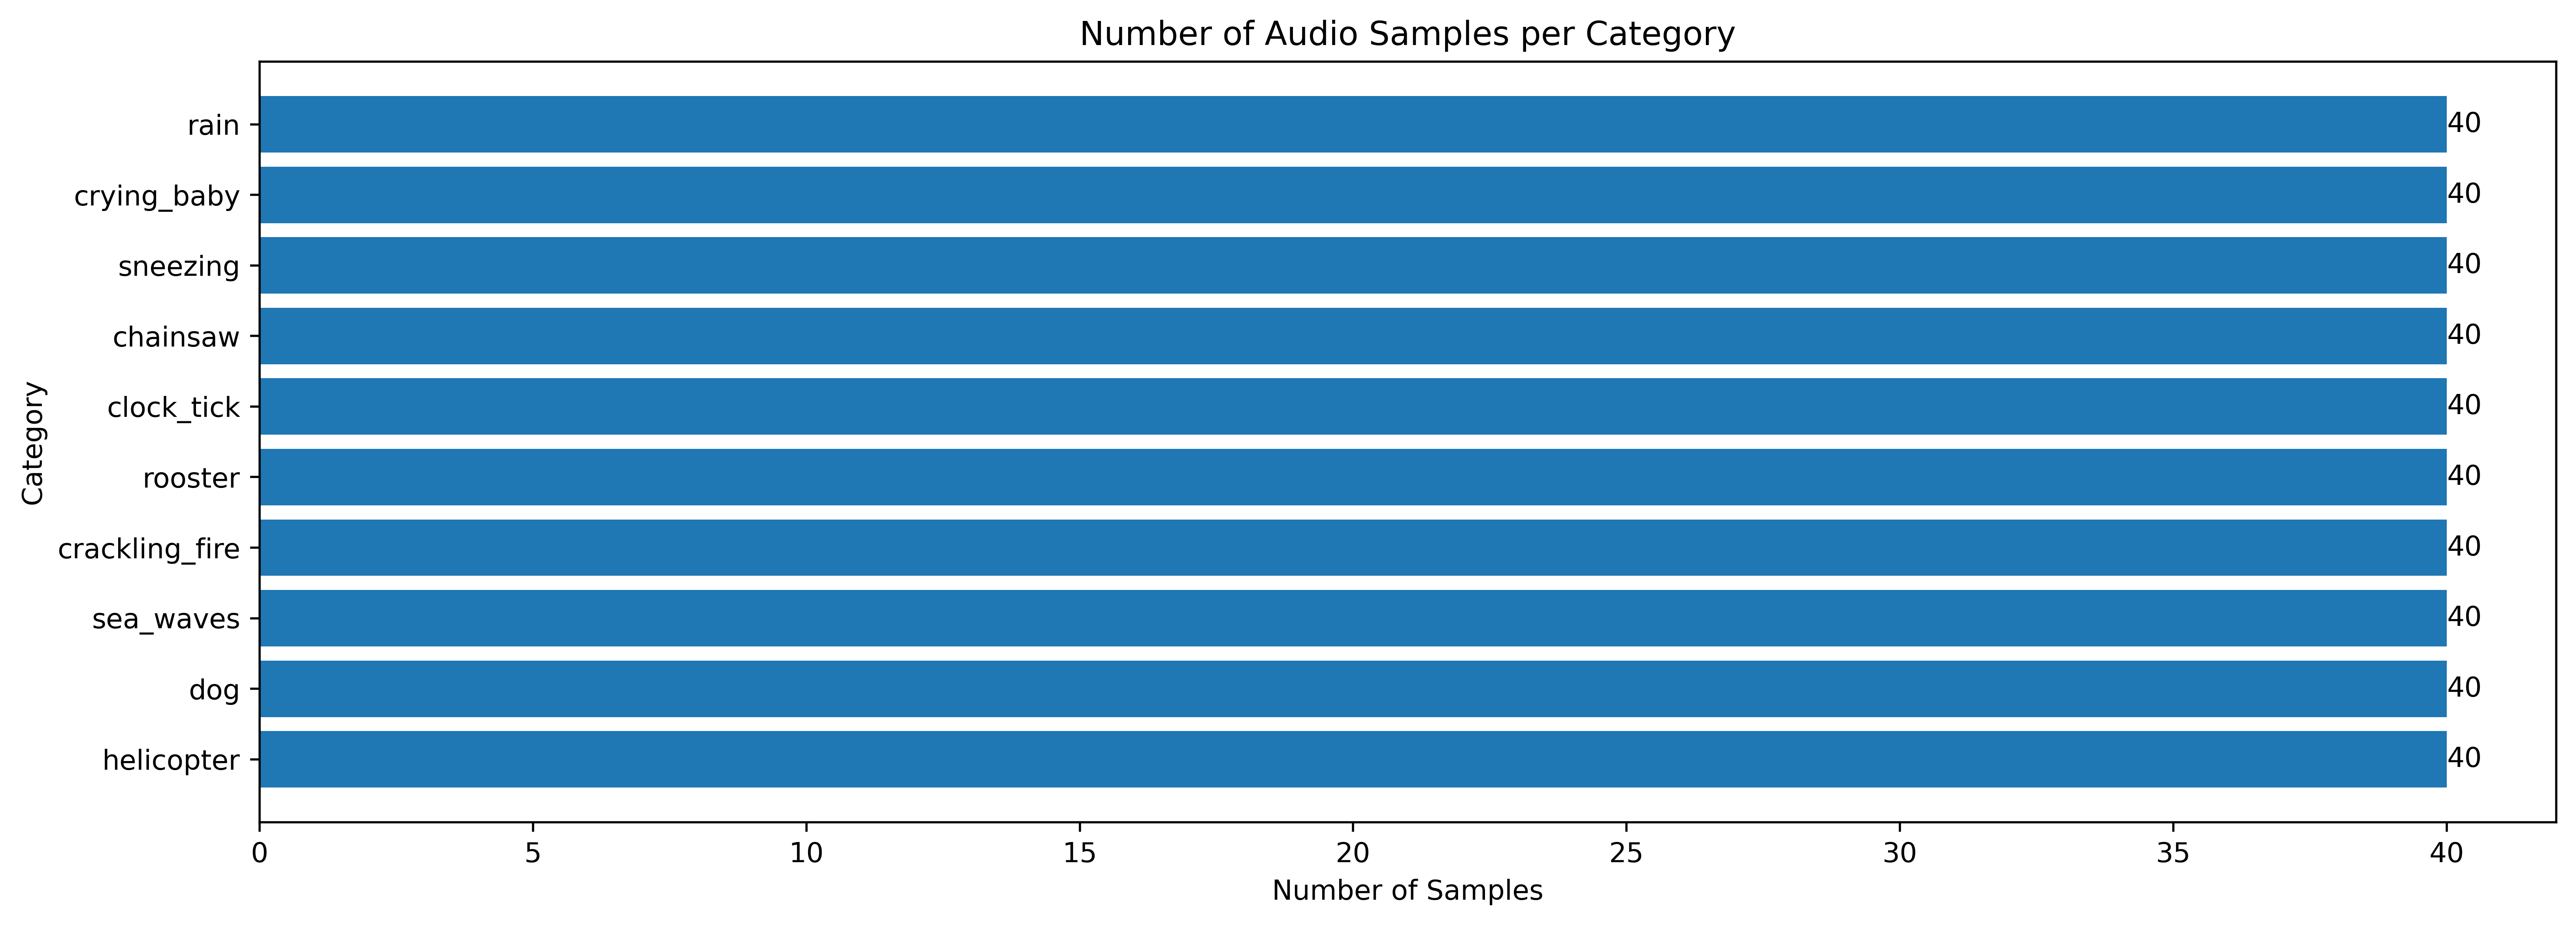

In [18]:
x = df["class"].unique()
y = df["class"].value_counts(ascending=True)
ind = np.arange(len(y))
# plt.figure()
fig, ax = plt.subplots(figsize=(15, 5))
ax.barh(ind, y)
ax.set_yticks(ind)
ax.set_yticklabels(x)
ax.bar_label(ax.containers[0])
plt.gcf().set_dpi(500)
plt.title("Number of Audio Samples per Category")
plt.xlabel("Number of Samples")
plt.ylabel("Category")
plt.show()

Poniższy kod:

1. przechodzi przez wszystkie pliki audio,
2. wczytuje każdy .wav,
3. wyciąga cechy MFCC,
4. zamienia je na wektor liczb,
5. tworzy dataset gotowy do uczenia modelu ML.



In [19]:
extracted = []

for index_num, row in tqdm(df.iterrows()):
    file_name = os.path.join(os.path.abspath(DATA_PATH) + "/" + str(row["class"]) + "/" + str(row["file"]))
    final_class_labels = row["class"]
    # load the audio file
    audio, sample_rate = librosa.load(file_name, res_type="kaiser_fast")
    # extract the features
    feature = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=128)
    # feature scaling
    scaled_feature = np.mean(feature.T, axis=0)
    # store it in a list
    extracted.append([scaled_feature, final_class_labels])

extracted_df = pd.DataFrame(extracted, columns=["feature", "class"])
extracted_df.head()

400it [00:30, 13.06it/s]


,feature,class
0,"[-91.76743, 90.65687, 27.062613, 9.311692, 23....",helicopter
1,"[-24.806883, 116.619484, -26.590633, 39.35859,...",helicopter
2,"[-296.23514, 172.88437, 7.781424, -1.7111038, ...",helicopter
3,"[-408.06793, 223.67892, 98.823586, 18.655926, ...",helicopter
4,"[-184.43994, 160.84584, 37.406876, 32.59519, 2...",helicopter


In [23]:
X = np.array(extracted_df["feature"].tolist())
y = np.array(extracted_df["class"].tolist())

# label encoding to get encoding
le = LabelEncoder()
# transform each category with it's respected label
Y = to_categorical(le.fit_transform(y))

In [24]:
# split the data to train and test set
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# print the details
print("Number of training samples = ", X_train.shape[0])
print("Number of testing samples = ", X_test.shape[0])

Number of training samples =  320
Number of testing samples =  80


Tworzymy model sieci neuronowej

In [25]:
num_labels = Y.shape[1]
ANN_Model = Sequential()
ANN_Model.add(Dense(1000, activation="relu", input_shape=(128,)))
ANN_Model.add(Dense(750, activation="relu"))
ANN_Model.add(Dense(500, activation="relu"))
ANN_Model.add(Dropout(0.3))
ANN_Model.add(Dense(250, activation="relu"))
ANN_Model.add(Dense(100, activation="relu"))
ANN_Model.add(Dense(50, activation="relu"))
ANN_Model.add(Dense(num_labels, activation="softmax"))

ANN_Model.compile(
    optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"]
)

ANN_Model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1000)           │       129,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 750)            │       750,750 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 500)            │       375,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 250)            │       125,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        25,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,411,160 (5.38 MB)

 Trainable params: 1,411,160 (5.38 MB)

 Non-trainable params: 0 (0.00 B)

Poniższy kod:
1. trenuje model neuronowy,
2. zapisuje wytrenowany model,
3. zapisuje historię treningu,

In [26]:
num_epochs = 150
num_batch_size = 32

t0 = time.time()
ANN_Results = ANN_Model.fit(
    X_train,
    y_train,
    batch_size=num_batch_size,
    epochs=num_epochs,
    validation_data=(X_test, y_test),
)

ANN_Model.save("Model1.h5")
print("ANN Model Saved")
train_hist_m1 = pd.DataFrame(ANN_Results.history)
train_m1 = round(time.time() - t0, 3)

Epoch 1/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.1094 - loss: 4.6600 - val_accuracy: 0.1375 - val_loss: 2.7171
Epoch 2/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.2031 - loss: 2.5981 - val_accuracy: 0.2250 - val_loss: 2.0185
Epoch 3/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.2500 - loss: 2.0799 - val_accuracy: 0.3000 - val_loss: 1.8051
Epoch 4/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.3000 - loss: 1.8660 - val_accuracy: 0.4000 - val_loss: 1.6338
Epoch 5/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.3187 - loss: 1.7468 - val_accuracy: 0.4250 - val_loss: 1.6291
Epoch 6/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4500 - loss: 1.5193 - val_accuracy: 0.5875 - val_loss: 1.2708
Epoch 7/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5125 - loss: 1.3108 - val_accuracy: 0.5125 - val_loss: 1.1869
Epoch 8/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5688 - loss: 1.1921 - val_accuracy: 0.

ANN Model Saved


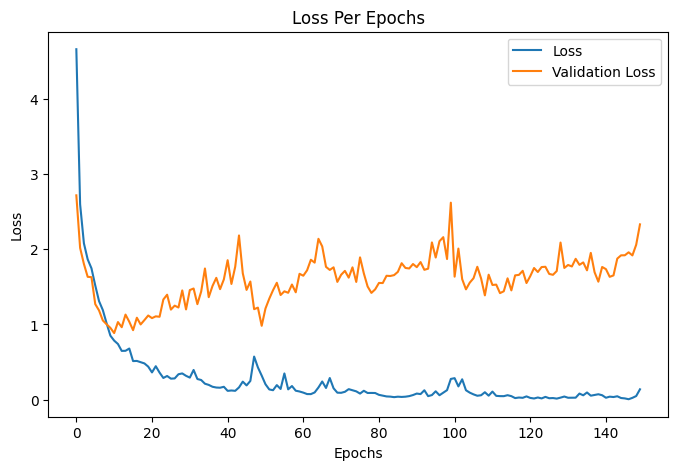

In [27]:
plt.figure(figsize=(8, 5))
plt.plot(train_hist_m1[["loss", "val_loss"]])
plt.legend(["Loss", "Validation Loss"])
plt.title("Loss Per Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

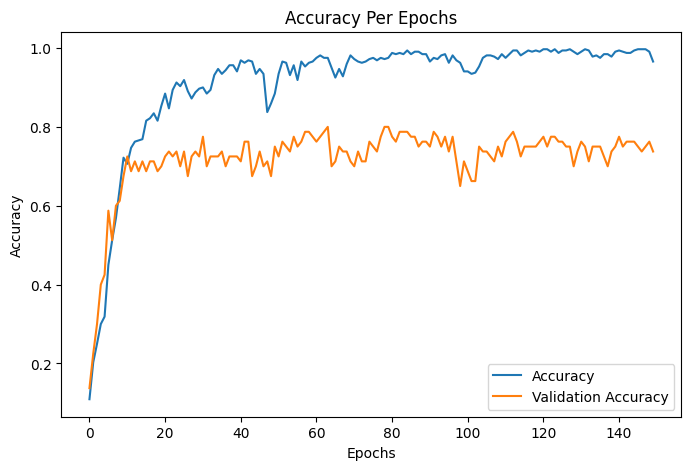

In [28]:
plt.figure(figsize=(8, 5))
plt.plot(train_hist_m1[["accuracy", "val_accuracy"]])
plt.legend(["Accuracy", "Validation Accuracy"])
plt.title("Accuracy Per Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

Ten kod tworzy system do porównywania modeli ML/AI — zapisuje accuracy, czas treningu i czas predykcji do jednej tabeli

In [29]:
log_cols = ["model", "accuracy", "train_time", "pred_time"]
log = pd.DataFrame(columns=log_cols)

def Log_Model(model, model_name, x, y, t):
    global log
    acc = model.evaluate(x, y, verbose=0)
    t0 = time.time()
    y_pred = model.predict(x, verbose=0)
    pred = round(time.time() - t0, 3)
    log_entry = pd.DataFrame([[model_name, acc[1] * 100, t, pred]], columns=log_cols)
    log = pd.concat([log, log_entry], ignore_index=True)

In [30]:
Log_Model(ANN_Model, "ANN", X_test, y_test, train_m1)
log

,model,accuracy,train_time,pred_time
0,ANN,73.750001,69.78,0.451


In [32]:
def ANN_Prediction(file_name):
    # load the audio file
    audio_data, sample_rate = librosa.load(file_name, res_type="kaiser_fast")
    # get the feature
    feature = librosa.feature.mfcc(y=audio_data, sr=sample_rate, n_mfcc=128)
    # scale the features
    feature_scaled = np.mean(feature.T, axis=0)
    # array of features
    prediction_feature = np.array([feature_scaled])
    # get the id of label using argmax
    predicted_vector = np.argmax(ANN_Model.predict(prediction_feature), axis=-1)
    # get the class label from class id
    predicted_class = le.inverse_transform(predicted_vector)
    # display the result
    print("ANN has predicted the class as  --> ", predicted_class[0])

# File name
file_name = DATA_PATH + "/rooster/2-96460-A-1.wav"
# get the output
ANN_Prediction(file_name)
# play the file
ipd.Audio(file_name)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
ANN has predicted the class as  -->  rooster


In [33]:
xTrainval, xTest, yTrainval, yTest = train_test_split(
    X, Y, test_size=0.1, stratify=y, random_state=387
)
xTrain, xvalid, yTrain, yvalid = train_test_split(
    xTrainval, yTrainval, test_size=0.2, stratify=yTrainval, random_state=387
)
print("\nNumber of samples for Train set :", xTrain.shape[0])
print("Number of samples for Validation set :", xvalid.shape[0])
print("Number of samples for Test set :", xTest.shape[0])

xTrain = np.expand_dims(xTrain, axis=2)
xvalid = np.expand_dims(xvalid, axis=2)

print("Shape of X Train", xTrain.shape)
print("Shape of X Test", xTest.shape)


Number of samples for Train set : 288
Number of samples for Validation set : 72
Number of samples for Test set : 40
Shape of X Train (288, 128, 1)
Shape of X Test (40, 128)


Tworzymy model sieci CNN

In [34]:
CNN1D_Model = Sequential()
CNN1D_Model.add(
    Conv1D(
        256,
        5,
        strides=1,
        padding="same",
        activation="relu",
        input_shape=(xTrain.shape[1], 1),
    )
)
CNN1D_Model.add(BatchNormalization())
CNN1D_Model.add(MaxPooling1D(3, strides=2, padding="same"))
CNN1D_Model.add(Conv1D(128, 5, strides=1, padding="same", activation="relu"))
CNN1D_Model.add(Dropout(0.3))
CNN1D_Model.add(MaxPooling1D(3, strides=2, padding="same"))
CNN1D_Model.add(Conv1D(128, 5, strides=1, padding="same", activation="relu"))
CNN1D_Model.add(Dropout(0.2))
CNN1D_Model.add(MaxPooling1D(3, strides=2, padding="same"))
CNN1D_Model.add(Conv1D(64, 5, strides=1, padding="same", activation="relu"))
CNN1D_Model.add(Dropout(0.3))
CNN1D_Model.add(MaxPooling1D(3, strides=2, padding="same"))
CNN1D_Model.add(Flatten())
CNN1D_Model.add(Dense(units=1024, activation="relu"))
CNN1D_Model.add(Dropout(0.2))
CNN1D_Model.add(Dense(units=num_labels, activation="softmax"))
CNN1D_Model.compile(
    optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"]
)
CNN1D_Model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 128, 256)       │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 64, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 64, 128)        │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 32, 128)        │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 16, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 16, 64)         │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 8, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 825,162 (3.15 MB)

 Trainable params: 824,650 (3.15 MB)

 Non-trainable params: 512 (2.00 KB)

In [35]:
t0 = time.time()

CNN1D_Results = CNN1D_Model.fit(
    xTrain, yTrain, batch_size=num_batch_size, epochs=num_epochs, validation_data=(xvalid, yvalid)
)

CNN1D_Model.save("Model2.h5")
print("CNN1D Model Saved")
train_hist_m2 = pd.DataFrame(CNN1D_Results.history)
train_m2 = round(time.time() - t0, 3)

Epoch 1/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 165ms/step - accuracy: 0.1701 - loss: 2.6349 - val_accuracy: 0.1528 - val_loss: 2.1047
Epoch 2/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step - accuracy: 0.3542 - loss: 1.8932 - val_accuracy: 0.1250 - val_loss: 2.5502
Epoch 3/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 124ms/step - accuracy: 0.5000 - loss: 1.4936 - val_accuracy: 0.3194 - val_loss: 2.5611
Epoch 4/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 124ms/step - accuracy: 0.5590 - loss: 1.2860 - val_accuracy: 0.2639 - val_loss: 1.9605
Epoch 5/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step - accuracy: 0.6389 - loss: 1.1271 - val_accuracy: 0.4444 - val_loss: 1.4311
Epoch 6/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step - accuracy: 0.6528 - loss: 0.9631 - val_accuracy: 0.2361 - val_loss: 1.9249
Epoch 7/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 124ms/step - accuracy: 0.6944 - loss: 0.9355 - val_accuracy: 0.4444 - val_loss: 1.3766
Epoch 8/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step - accuracy: 0.6875 - loss: 0.8979 - val_accuracy: 0.4444 - v

CNN1D Model Saved


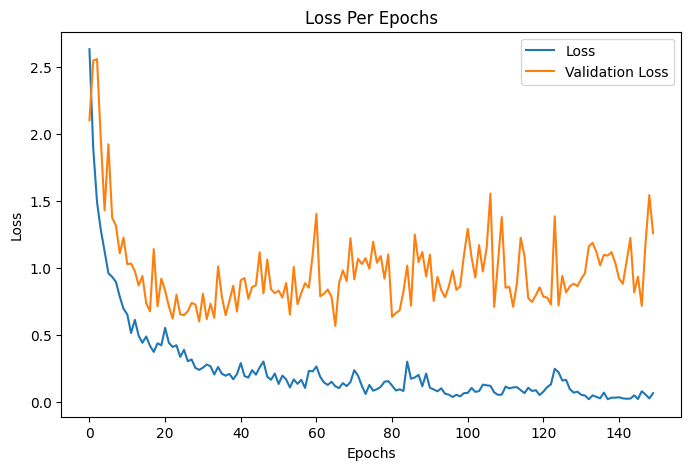

In [36]:
plt.figure(figsize=(8, 5))
plt.plot(train_hist_m2[["loss", "val_loss"]])
plt.legend(["Loss", "Validation Loss"])
plt.title("Loss Per Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

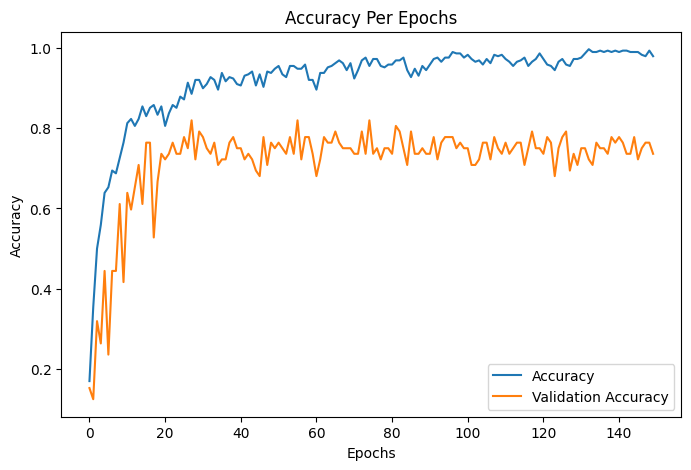

In [37]:
plt.figure(figsize=(8, 5))
plt.plot(train_hist_m2[["accuracy", "val_accuracy"]])
plt.legend(["Accuracy", "Validation Accuracy"])
plt.title("Accuracy Per Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

In [38]:
Log_Model(CNN1D_Model, "CNN1D", xvalid, yvalid, train_m2)
log

,model,accuracy,train_time,pred_time
0,ANN,73.750001,69.780,0.451
1,CNN1D,73.611110,226.558,0.401


In [40]:
def CNN1D_Prediction(file_name):
    # load the audio file
    audio_data, sample_rate = librosa.load(file_name, res_type="kaiser_fast")
    # get the feature
    feature = librosa.feature.mfcc(y=audio_data, sr=sample_rate, n_mfcc=128)
    # scale the features
    feature_scaled = np.mean(feature.T, axis=0)
    # array of features
    prediction_feature = np.array([feature_scaled])
    # expand dims
    final_prediction_feature = np.expand_dims(prediction_feature, axis=2)
    # get the id of label using argmax
    predicted_vector = np.argmax(CNN1D_Model.predict(final_prediction_feature), axis=-1)
    # get the class label from class id
    predicted_class = le.inverse_transform(predicted_vector)
    # display the result
    print("CNN1D has predicted the class as  --> ", predicted_class[0])

# File name
file_name = DATA_PATH + "/rain/4-161127-A-10.wav"
# get the output
CNN1D_Prediction(file_name)
# play the file
ipd.Audio(file_name)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
CNN1D has predicted the class as  -->  rain


In [41]:
xtrain = xTrain.reshape(xTrain.shape[0], 16, 8, 1)
xtest = xTest.reshape(xTest.shape[0], 16, 8, 1)

print("The Shape of X Train", xtrain.shape)
print("The Shape of Y Train", yTrain.shape)
print("The Shape of X Test", xtest.shape)
print("The Shape of Y Test", yTest.shape)

The Shape of X Train (288, 16, 8, 1)
The Shape of Y Train (288, 10)
The Shape of X Test (40, 16, 8, 1)
The Shape of Y Test (40, 10)


In [42]:
CNN2D_Model = Sequential()
CNN2D_Model.add(
    Conv2D(64, (3, 3), padding="same", activation="tanh", input_shape=(16, 8, 1))
)
CNN2D_Model.add(MaxPool2D(pool_size=(2, 2)))
CNN2D_Model.add(Conv2D(128, (3, 3), padding="same", activation="tanh"))
CNN2D_Model.add(MaxPool2D(pool_size=(2, 2)))
CNN2D_Model.add(Dropout(0.2))
CNN2D_Model.add(Flatten())
CNN2D_Model.add(Dense(1024, activation="tanh"))
CNN2D_Model.add(Dense(128, activation="relu"))
CNN2D_Model.add(Dense(num_labels, activation="softmax"))
CNN2D_Model.compile(
    optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"]
)
CNN2D_Model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 16, 8, 64)      │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 8, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 4, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,256,586 (4.79 MB)

 Trainable params: 1,256,586 (4.79 MB)

 Non-trainable params: 0 (0.00 B)

In [43]:
t0 = time.time()

CNN2D_Results = CNN2D_Model.fit(
    xtrain, yTrain, epochs=num_epochs, batch_size=num_batch_size, validation_data=(xtest, yTest)
)

CNN2D_Model.save("Model3.h5")
print("CNN2D Model Saved")
train_hist_m3 = pd.DataFrame(CNN2D_Results.history)
train_m3 = round(time.time() - t0, 3)

Epoch 1/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - accuracy: 0.2326 - loss: 2.1676 - val_accuracy: 0.4000 - val_loss: 1.7971
Epoch 2/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.5729 - loss: 1.2400 - val_accuracy: 0.5000 - val_loss: 1.5176
Epoch 3/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.6771 - loss: 0.8712 - val_accuracy: 0.6000 - val_loss: 1.4288
Epoch 4/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.7847 - loss: 0.6303 - val_accuracy: 0.5000 - val_loss: 1.6251
Epoch 5/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.8507 - loss: 0.4937 - val_accuracy: 0.6250 - val_loss: 1.2221
Epoch 6/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.8993 - loss: 0.3293 - val_accuracy: 0.6000 - val_loss: 1.3359
Epoch 7/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9444 - loss: 0.2278 - val_accuracy: 0.6750 - val_loss: 1.2417
Epoch 8/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9583 - loss: 0.1695 - val_accuracy: 0.6500 - val_loss:

CNN2D Model Saved


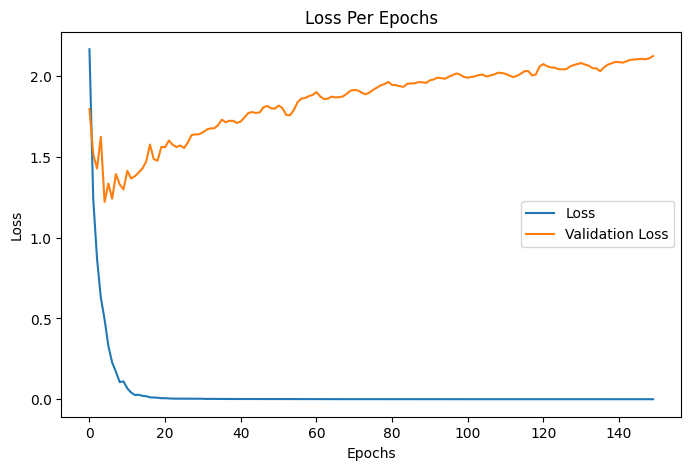

In [44]:
plt.figure(figsize=(8, 5))
plt.plot(train_hist_m3[["loss", "val_loss"]])
plt.legend(["Loss", "Validation Loss"])
plt.title("Loss Per Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

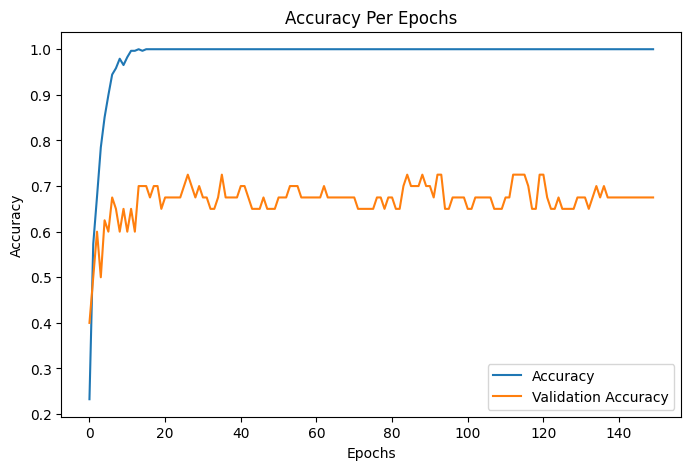

In [45]:
plt.figure(figsize=(8, 5))
plt.plot(train_hist_m3[["accuracy", "val_accuracy"]])
plt.legend(["Accuracy", "Validation Accuracy"])
plt.title("Accuracy Per Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

In [46]:
Log_Model(CNN2D_Model, "CNN2D", xtest, yTest, train_m3)
log

,model,accuracy,train_time,pred_time
0,ANN,73.750001,69.780,0.451
1,CNN1D,73.611110,226.558,0.401
2,CNN2D,67.500001,98.807,0.346


In [48]:
# function to predict the feature
def CNN2D_Prediction(file_name):
    # load the audio file
    audio_data, sample_rate = librosa.load(file_name, res_type="kaiser_fast")
    # get the feature
    feature = librosa.feature.mfcc(y=audio_data, sr=sample_rate, n_mfcc=128)
    # scale the features
    feature_scaled = np.mean(feature.T, axis=0)
    # array of features
    prediction_feature = np.array([feature_scaled])
    # reshaping the features
    final_prediction_feature = prediction_feature.reshape(
        prediction_feature.shape[0], 16, 8, 1
    )
    # get the id of label using argmax
    predicted_vector = np.argmax(CNN2D_Model.predict(final_prediction_feature), axis=-1)
    # get the class label from class id
    predicted_class = le.inverse_transform(predicted_vector)
    # display the result
    print("CNN2D has predicted the class as  --> ", predicted_class[0])

# File name
file_name = DATA_PATH + "/dog/2-114587-A-0.wav"
# get the output
CNN2D_Prediction(file_name)
# play the file
ipd.Audio(file_name)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
CNN2D has predicted the class as  -->  dog


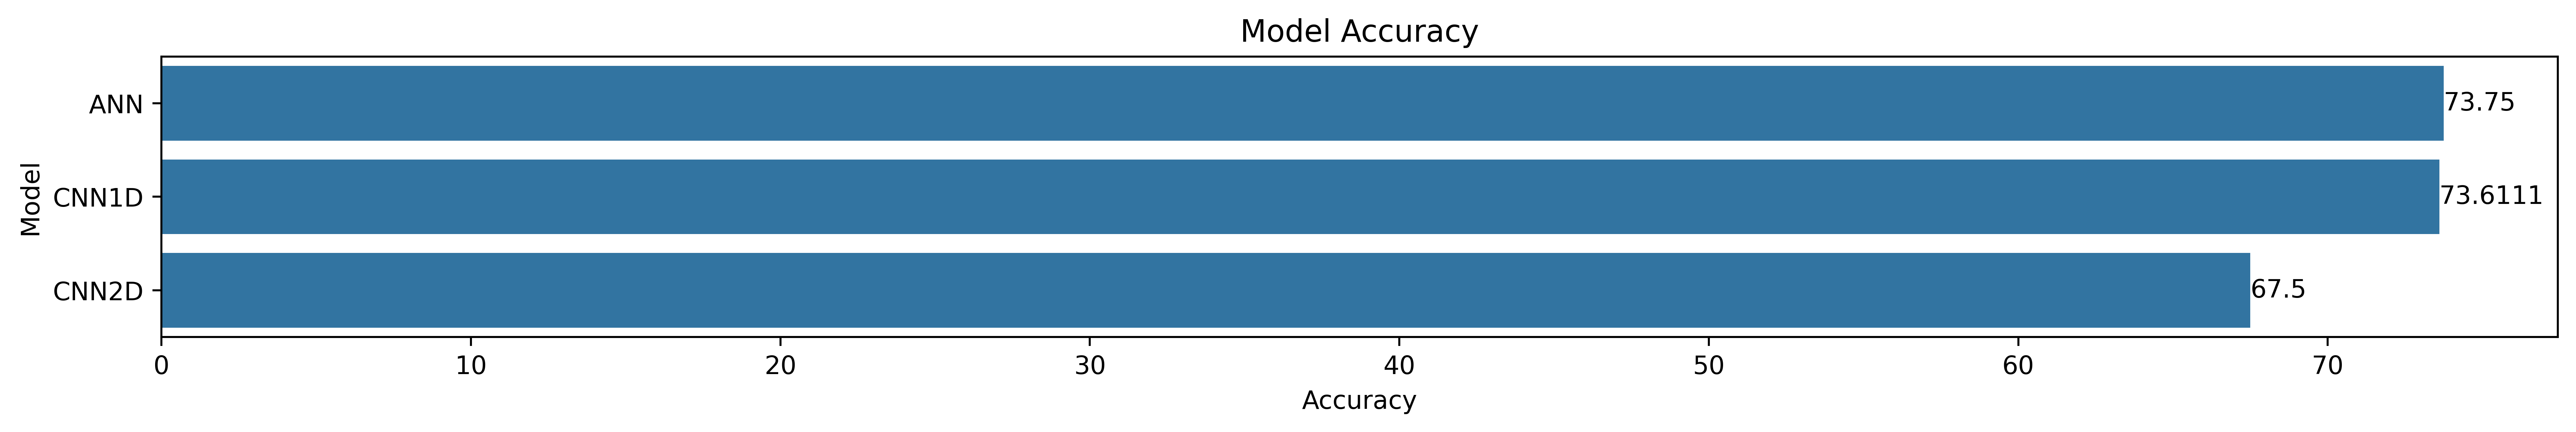

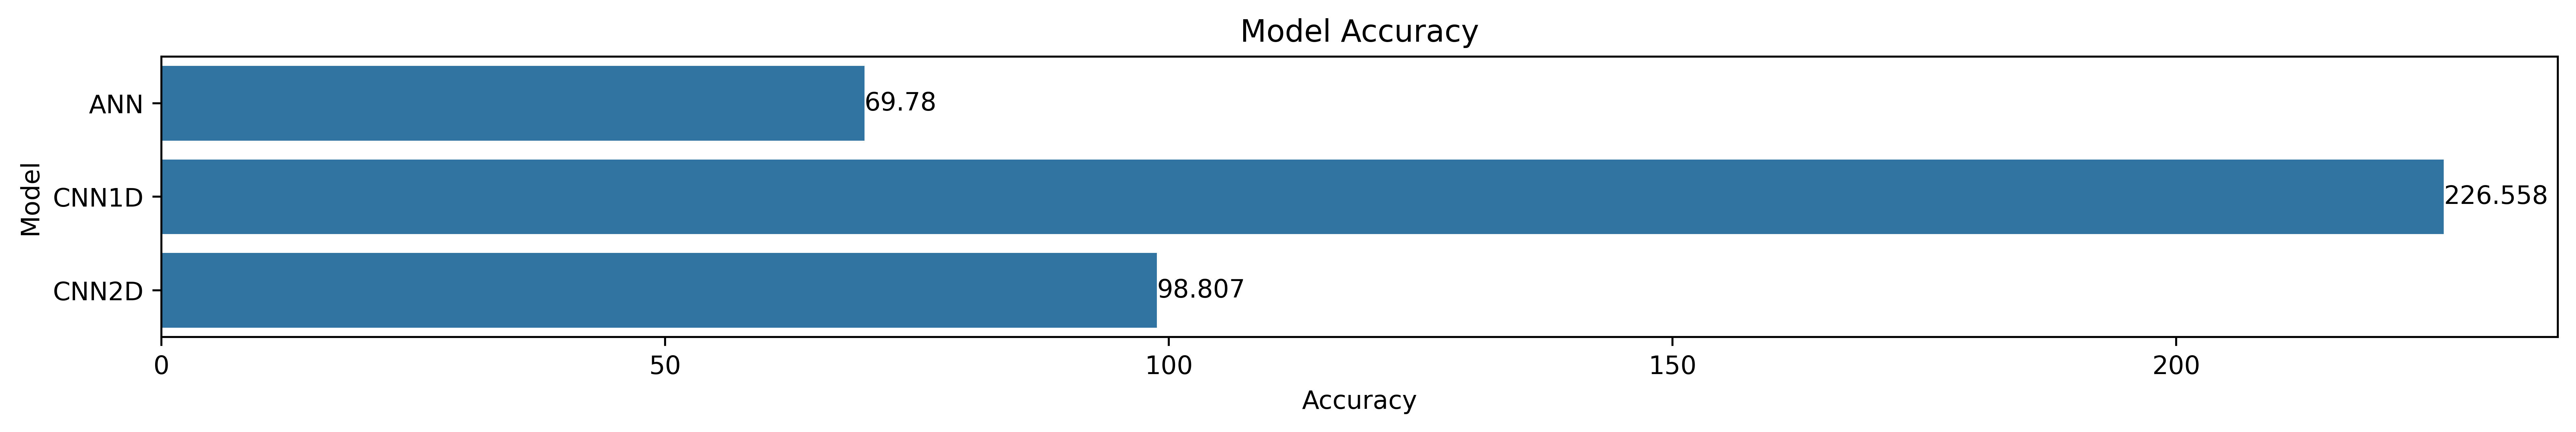

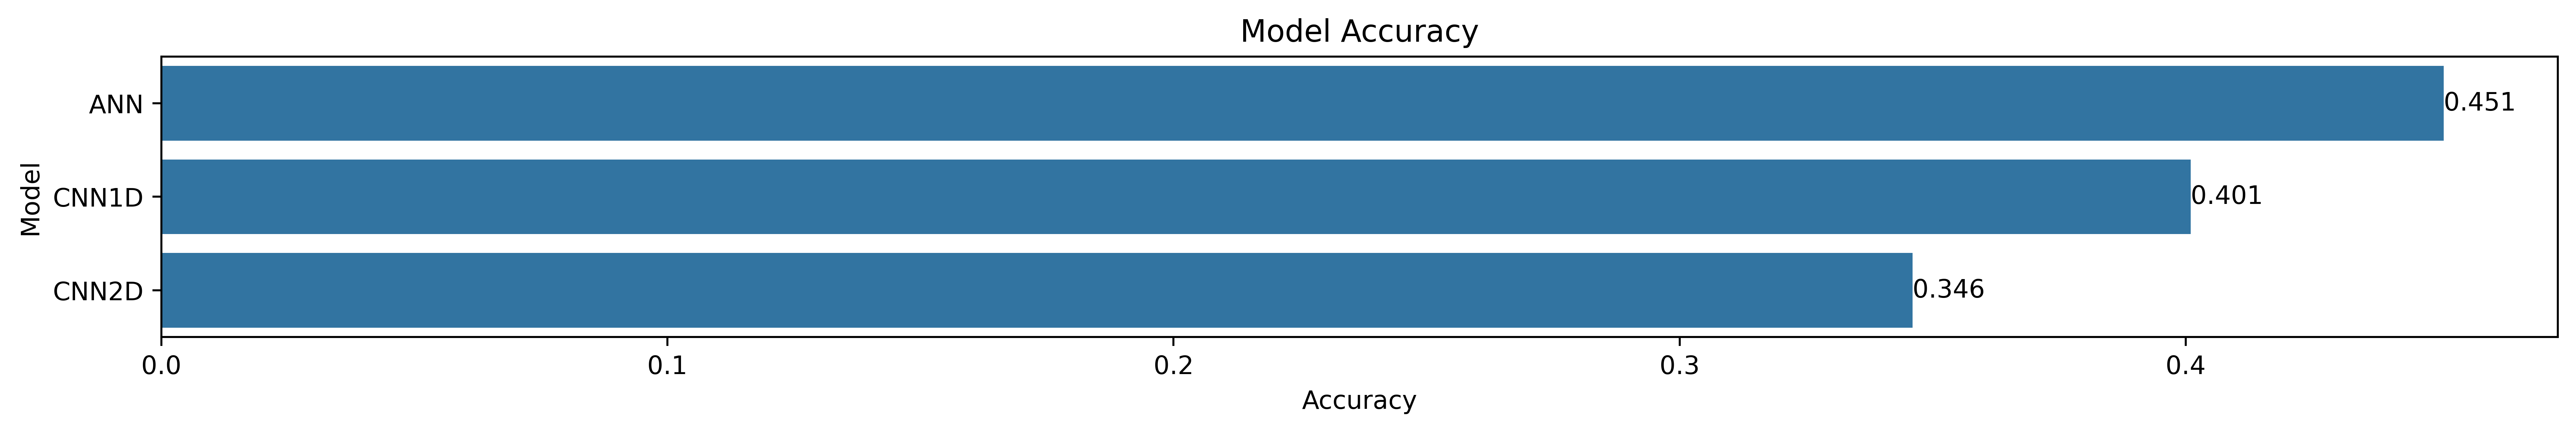

In [49]:
plt.rcParams["figure.figsize"] = (17, 2)
plt.rcParams["figure.dpi"] = 550

def plot_log(what):
    ax = sns.barplot(x=what, y="model", data=log)
    ax.bar_label(ax.containers[0])
    plt.xlabel("Accuracy")
    plt.ylabel("Model")
    plt.title("Model Accuracy")
    return plt.show()

plot_log("accuracy")
plot_log("train_time")
plot_log("pred_time")